# Deliverable 7b — Cascade + **Tumor Oversampling** + Aug + **Tversky-only**

> Two changes vs D7 (motivated by D7's diagnostic):
> 1. **Oversampling** — `WeightedRandomSampler` that draws tumor-containing slices 3:1 vs liver-only.
> 2. **Drop CE from the loss** — D7's diagnostic showed >50% of tumor slices got empty predictions. Likely cause: CE on imbalanced binary targets pulls every pixel toward background and dominates the Tversky gradient. Pure Tversky (β > α) should let the model predict tumor more readily.

### What changed vs D7
| Knob | D7 | **D7b** |
|------|----|---------|
| Train sampler | shuffle=True (uniform, ~33% tumor) | **WeightedRandomSampler, ratio=3.0 (~60% tumor)** |
| Loss | combined Tversky + CE | **Tversky-only** (α=0.3, β=0.7) |
| All other hyperparams | — | **identical** |

### Honest caveats
1. **Two simultaneous changes** — if D7b > D7, we can't cleanly attribute the gain to one. Both target the same failure mode (timid empty predictions), so we're hedging on purpose.
2. **Same Stage-1, same val set, same seed.** Cascade architecture is unchanged.
3. **Headline = end-to-end Dice (Section 9)**. Per-slice empty rate is also tracked to monitor the timid-prediction issue.

## 1. Imports

In [1]:
import os, json, time, copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from lits_core import (get_device, load_lits_paths, make_split,
                       LiTS25DDataset, UNet2D, compute_dice_per_class)
from lits_cascade import (combined_tversky_loss, tversky_loss,
                          LiTSLiverCroppedDataset, liver_bbox,
                          stage1_predict_liver_mask,
                          make_tumor_oversampler)

device = get_device()
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.11.0+cu128


## 2. Configuration (identical to D7 except OVERSAMPLE_RATIO)

In [2]:
DATA_DIR    = '/home/adnan/aeman_dl/archive-2'
OUT_DIR     = './out_d7b_oversample'
TAG         = 'D7b-oversample'

IMG_SIZE    = 128
STACK_SIZE  = 5
SEED        = 42

STAGE1_CKPT = './out_d6c_v2/best_unet_d6c_v2.pth'
STAGE1_DROPOUT_P = 0.3

S2_BATCH       = 16
S2_NUM_EPOCHS  = 30
S2_LR          = 1e-4
S2_WD          = 1e-5
S2_ETA_MIN     = 1e-7
S2_PAD_FRAC    = 0.05
S2_TVERSKY_A   = 0.3
S2_TVERSKY_B   = 0.7
S2_AUG         = True
S2_AUG_STR     = 'medium'

# *** D7b NEW HYPERPARAM ***
OVERSAMPLE_RATIO = 3.0     # tumor slices weighted 3x vs liver-only

os.makedirs(OUT_DIR, exist_ok=True)
print(f'Stage-1 checkpoint: {STAGE1_CKPT}')
print(f'Stage-2: {S2_NUM_EPOCHS} epochs | bs={S2_BATCH} | LR cosine {S2_LR}->{S2_ETA_MIN}')
print(f'Stage-2 loss: Tversky-only (a={S2_TVERSKY_A}, b={S2_TVERSKY_B})  *** NEW vs D7 ***')
print(f'Stage-2 aug: {S2_AUG} ({S2_AUG_STR})')
print(f'>>> NEW: tumor oversample ratio = {OVERSAMPLE_RATIO}x')

Stage-1 checkpoint: ./out_d6c_v2/best_unet_d6c_v2.pth
Stage-2: 30 epochs | bs=16 | LR cosine 0.0001->1e-07
Stage-2 loss: Tversky-only (a=0.3, b=0.7)  *** NEW vs D7 ***
Stage-2 aug: True (medium)
>>> NEW: tumor oversample ratio = 3.0x


## 3. Data Loading & Split (same seed=42 as D7)

In [3]:
volume_paths, seg_paths = load_lits_paths(DATA_DIR)
train_v, train_s, val_v, val_s, test_v, test_s = make_split(
    volume_paths, seg_paths, seed=SEED)

Found 51 matched volume-segmentation pairs
Split — Train: 35 | Val: 8 | Test: 8


## 4. Stage-1 (D6c-v2, frozen) — identical to D7

In [4]:
stage1 = UNet2D(in_channels=STACK_SIZE, num_classes=3, base_features=64,
                use_attention=False).to(device)
original_bn = stage1.bottleneck
stage1.bottleneck = nn.Sequential(original_bn, nn.Dropout2d(p=STAGE1_DROPOUT_P)).to(device)

if not os.path.exists(STAGE1_CKPT):
    raise FileNotFoundError(f'Stage-1 checkpoint not found at {STAGE1_CKPT}.')

state = torch.load(STAGE1_CKPT, map_location=device)
stage1.load_state_dict(state)
stage1.eval()
for p in stage1.parameters():
    p.requires_grad = False
print(f'Stage-1 loaded and frozen. Params: {sum(p.numel() for p in stage1.parameters()):,}')

Stage-1 loaded and frozen. Params: 31,038,915


## 5. Stage-2 Datasets — Liver-Cropped, Augmented

Identical to D7. The change is at the loader stage (next cell).

In [5]:
print('Building Stage-2 train (cropped, aug=ON)...')
s2_train = LiTSLiverCroppedDataset(
    train_v, train_s, img_size=IMG_SIZE, stack_size=STACK_SIZE,
    pad_frac=S2_PAD_FRAC, augment=S2_AUG, aug_strength=S2_AUG_STR)

print('\nBuilding Stage-2 val (cropped, aug=OFF)...')
s2_val = LiTSLiverCroppedDataset(
    val_v, val_s, img_size=IMG_SIZE, stack_size=STACK_SIZE,
    pad_frac=S2_PAD_FRAC, augment=False)

# *** D7b CHANGE: WeightedRandomSampler instead of shuffle=True ***
sampler = make_tumor_oversampler(s2_train, ratio=OVERSAMPLE_RATIO)

s2_train_loader = DataLoader(s2_train, batch_size=S2_BATCH, sampler=sampler,
                             num_workers=0, pin_memory=False)
s2_val_loader   = DataLoader(s2_val,   batch_size=S2_BATCH, shuffle=False,
                             num_workers=0, pin_memory=False)
print(f'\nTrain batches: {len(s2_train_loader)} | Val batches: {len(s2_val_loader)}')

Building Stage-2 train (cropped, aug=ON)...
CroppedDataset: 4614 slices (1594 with tumor, 3020 liver-only) | skipped 8101 bg-only | stack=5 | augment=True (medium)

Building Stage-2 val (cropped, aug=OFF)...
CroppedDataset: 1116 slices (327 with tumor, 789 liver-only) | skipped 1474 bg-only | stack=5 | augment=False (medium)
Oversampler: ratio=3.0x | 1594 tumor + 3020 liver-only -> effective 61.3% tumor in each batch

Train batches: 289 | Val batches: 70


## 6. Build Stage-2 Model — same as D7

In [6]:
s2_model = UNet2D(in_channels=STACK_SIZE, num_classes=2, base_features=64,
                  use_attention=False).to(device)
n_params = sum(p.numel() for p in s2_model.parameters() if p.requires_grad)
print(f'Stage-2 model params: {n_params:,}')

with torch.no_grad():
    test_in = torch.randn(2, STACK_SIZE, IMG_SIZE, IMG_SIZE).to(device)
    test_out = s2_model(test_in)
    print(f'Forward: {tuple(test_in.shape)} -> {tuple(test_out.shape)}  (expect [2, 2, 128, 128])')

Stage-2 model params: 31,038,850
Forward: (2, 5, 128, 128) -> (2, 2, 128, 128)  (expect [2, 2, 128, 128])


## 7. Train Stage-2 — Tversky-only loss (no CE)

Same loop as D7, but the loss is `tversky_loss(α=0.3, β=0.7)` only — no cross-entropy term.

In [7]:
torch.manual_seed(SEED)

optimizer = torch.optim.Adam(s2_model.parameters(), lr=S2_LR, weight_decay=S2_WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=S2_NUM_EPOCHS, eta_min=S2_ETA_MIN)

history = {k: [] for k in
           ['train_loss', 'val_loss', 'val_tumor_dice', 'epoch_mins', 'lr']}
best_tumor = 0.0
best_state = None

print('=' * 78)
print(f'TRAINING: {TAG}  (cascade + oversample {OVERSAMPLE_RATIO}x + aug + Tversky-only)')
print(f'  Epochs={S2_NUM_EPOCHS} | LR={S2_LR}->{S2_ETA_MIN} (cosine) | WD={S2_WD}')
print(f'  Tversky-only alpha={S2_TVERSKY_A} beta={S2_TVERSKY_B} (no CE)')
print('=' * 78)

def tumor_dice_binary(preds, targets, smooth=1e-6):
    pred_cls = preds.argmax(dim=1)
    p = (pred_cls == 1).float()
    t = (targets == 1).float()
    inter = (p * t).sum()
    denom = p.sum() + t.sum()
    return ((2 * inter + smooth) / (denom + smooth)).item() if denom > 0 else 1.0

for epoch in range(1, S2_NUM_EPOCHS + 1):
    t0 = time.time()
    current_lr = optimizer.param_groups[0]['lr']

    s2_model.train()
    train_losses = []
    for bi, (ct, seg) in enumerate(s2_train_loader):
        ct, seg = ct.to(device), seg.to(device)
        optimizer.zero_grad()
        preds = s2_model(ct)
        loss = tversky_loss(preds, seg, num_classes=preds.shape[1], alpha=S2_TVERSKY_A, beta=S2_TVERSKY_B)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        if (bi + 1) % 100 == 0:
            print(f'  [{TAG}] Ep {epoch:02d} batch {bi+1}/{len(s2_train_loader)} '
                  f'loss={loss.item():.4f}')

    s2_model.eval()
    val_losses, tumors = [], []
    with torch.no_grad():
        for ct, seg in s2_val_loader:
            ct, seg = ct.to(device), seg.to(device)
            preds = s2_model(ct)
            val_losses.append(tversky_loss(
                preds, seg, num_classes=preds.shape[1], alpha=S2_TVERSKY_A, beta=S2_TVERSKY_B).item())
            tumors.append(tumor_dice_binary(preds, seg))

    m_train = float(np.mean(train_losses))
    m_val   = float(np.mean(val_losses))
    m_tumor = float(np.mean(tumors))
    em = (time.time() - t0) / 60

    history['train_loss'].append(m_train)
    history['val_loss'].append(m_val)
    history['val_tumor_dice'].append(m_tumor)
    history['epoch_mins'].append(em)
    history['lr'].append(current_lr)

    scheduler.step()

    flag = ''
    if m_tumor > best_tumor:
        best_tumor = m_tumor
        best_state = {k: v.cpu().clone() for k, v in s2_model.state_dict().items()}
        flag = ' *** BEST'

    print(f'[{TAG}] Ep {epoch:02d}/{S2_NUM_EPOCHS} | {em:4.1f}min | '
          f'LR={current_lr:.2e} | Train: {m_train:.4f} | Val: {m_val:.4f} | '
          f'Tumor: {m_tumor:.4f}{flag}')

save_path = os.path.join(OUT_DIR, 'best_stage2_tumor.pth')
if best_state is not None:
    torch.save(best_state, save_path)
    print(f'\nSaved Stage-2 best to {save_path}')

print(f'\n{TAG} Stage-2 best Tumor Dice (oracle bbox): {best_tumor:.4f}')

TRAINING: D7b-oversample  (cascade + oversample 3.0x + aug + Tversky-only)
  Epochs=30 | LR=0.0001->1e-07 (cosine) | WD=1e-05
  Tversky-only alpha=0.3 beta=0.7 (no CE)
  [D7b-oversample] Ep 01 batch 100/289 loss=0.7306
  [D7b-oversample] Ep 01 batch 200/289 loss=0.5859
[D7b-oversample] Ep 01/30 |  3.0min | LR=1.00e-04 | Train: 0.7457 | Val: 0.9532 | Tumor: 0.1056 *** BEST
  [D7b-oversample] Ep 02 batch 100/289 loss=0.7295
  [D7b-oversample] Ep 02 batch 200/289 loss=0.5974
[D7b-oversample] Ep 02/30 |  2.0min | LR=9.97e-05 | Train: 0.5202 | Val: 0.9094 | Tumor: 0.1302 *** BEST
  [D7b-oversample] Ep 03 batch 100/289 loss=0.2247
  [D7b-oversample] Ep 03 batch 200/289 loss=0.2669
[D7b-oversample] Ep 03/30 |  2.0min | LR=9.89e-05 | Train: 0.3441 | Val: 0.8685 | Tumor: 0.2432 *** BEST
  [D7b-oversample] Ep 04 batch 100/289 loss=0.3391
  [D7b-oversample] Ep 04 batch 200/289 loss=0.1279
[D7b-oversample] Ep 04/30 |  2.0min | LR=9.76e-05 | Train: 0.2355 | Val: 0.8485 | Tumor: 0.3469 *** BEST
  [D

## 8. Training Curves — D7b vs D7 reference line

Loaded D7 reference: oracle best = 0.5797


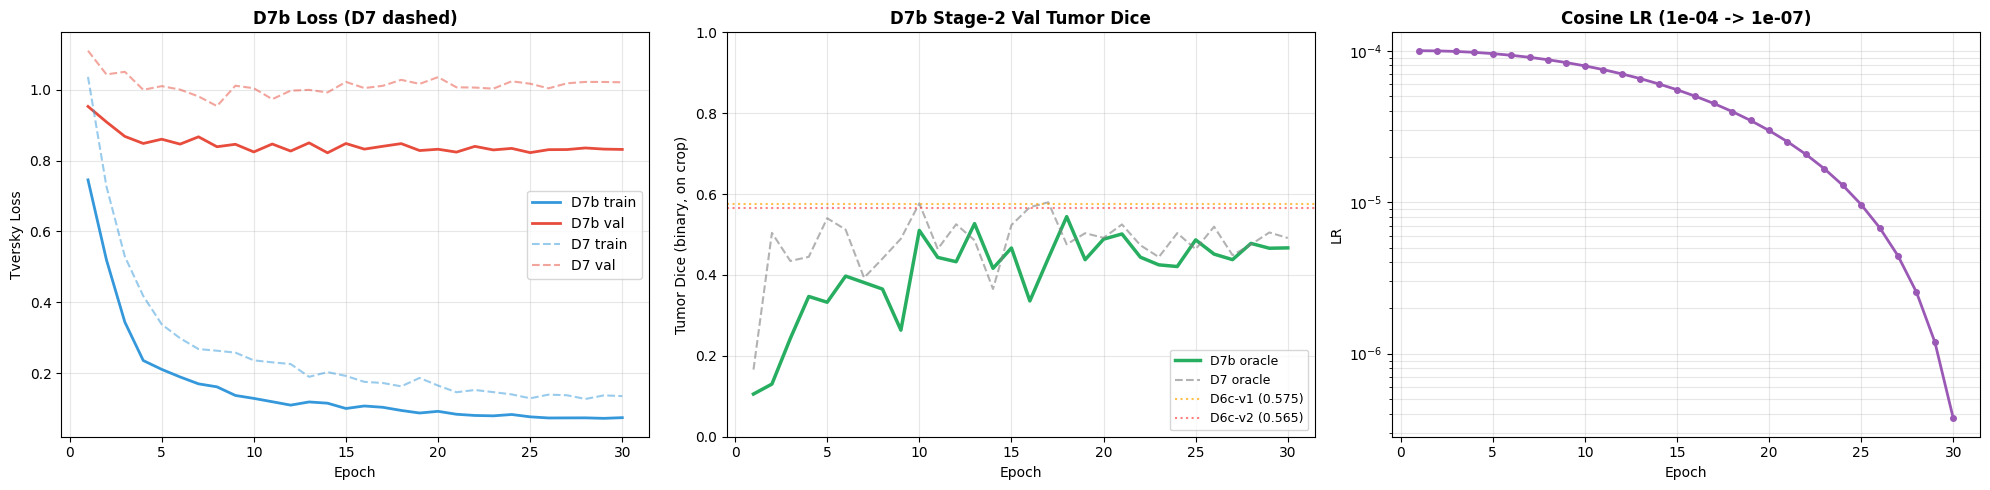

In [8]:
# Try to load D7's history for the comparison plot
d7_history = None
d7_best = None
d7_results_path = './out_d7_cascade/results.json'
if os.path.exists(d7_results_path):
    with open(d7_results_path) as f:
        d7_data = json.load(f)
    d7_history = d7_data.get('history', None)
    d7_best = d7_data.get('stage2_oracle_tumor_dice', None)
    print(f'Loaded D7 reference: oracle best = {d7_best:.4f}')
else:
    print('No D7 results.json found — plotting D7b alone.')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ep = range(1, S2_NUM_EPOCHS + 1)

axes[0].plot(ep, history['train_loss'], label='D7b train', color='#3498db', linewidth=2)
axes[0].plot(ep, history['val_loss'],   label='D7b val',   color='#e74c3c', linewidth=2)
if d7_history is not None:
    axes[0].plot(range(1, len(d7_history['train_loss']) + 1), d7_history['train_loss'],
                 ls='--', color='#3498db', alpha=0.5, label='D7 train')
    axes[0].plot(range(1, len(d7_history['val_loss']) + 1), d7_history['val_loss'],
                 ls='--', color='#e74c3c', alpha=0.5, label='D7 val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Tversky Loss')
axes[0].set_title('D7b Loss (D7 dashed)', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

D6CV1_TUMOR = 0.5749
D6CV2_TUMOR = 0.5649
axes[1].plot(ep, history['val_tumor_dice'], color='#27ae60', linewidth=2.5, label='D7b oracle')
if d7_history is not None:
    axes[1].plot(range(1, len(d7_history['val_tumor_dice']) + 1),
                 d7_history['val_tumor_dice'],
                 ls='--', color='gray', alpha=0.6, label='D7 oracle')
axes[1].axhline(D6CV1_TUMOR, ls=':', color='orange', alpha=0.7, label=f'D6c-v1 ({D6CV1_TUMOR:.3f})')
axes[1].axhline(D6CV2_TUMOR, ls=':', color='red',    alpha=0.5, label=f'D6c-v2 ({D6CV2_TUMOR:.3f})')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Tumor Dice (binary, on crop)')
axes[1].set_ylim(0, 1)
axes[1].set_title('D7b Stage-2 Val Tumor Dice', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9); axes[1].grid(alpha=0.3)

axes[2].plot(ep, history['lr'], color='#9b59b6', linewidth=2, marker='o', markersize=4)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].set_yscale('log')
axes[2].set_title(f'Cosine LR ({S2_LR:.0e} -> {S2_ETA_MIN:.0e})', fontweight='bold')
axes[2].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'training_curves_d7b.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. End-to-End Evaluation — same as D7 Section 9

In [9]:
s2_model.load_state_dict(best_state)
s2_model.eval()

import nibabel as nib
from scipy import ndimage

HU_MIN, HU_MAX = -100, 400

def normalize_ct(slice_2d):
    x = np.clip(slice_2d, HU_MIN, HU_MAX)
    return ((x - HU_MIN) / (HU_MAX - HU_MIN)).astype(np.float32)

def resize2d(arr, h, w, order):
    if arr.shape == (h, w):
        return arr
    return ndimage.zoom(arr, (h / arr.shape[0], w / arr.shape[1]), order=order)

@torch.no_grad()
def cascade_predict_slice(vol, seg_full, slice_idx, n_slices):
    """CORRECTED: bbox + crop done at full resolution to match training."""
    H, W = vol.shape[0], vol.shape[1]
    half = STACK_SIZE // 2
    stack_idxs = [max(0, min(n_slices - 1, slice_idx + off))
                  for off in range(-half, half + 1)]

    # Stage 1 input at 128x128
    ct_128_chs = [resize2d(normalize_ct(vol[:, :, i]), IMG_SIZE, IMG_SIZE, order=1)
                  for i in stack_idxs]
    ct_128 = np.stack(ct_128_chs, axis=0)
    ct_128_t = torch.from_numpy(ct_128).unsqueeze(0).to(device)
    s1_pred_128 = stage1(ct_128_t).argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
    liver_mask_128 = (s1_pred_128 > 0).astype(np.uint8)

    # Upsample Stage-1 mask to full res, compute bbox there
    liver_mask_full = resize2d(liver_mask_128.astype(np.float32),
                               H, W, order=0).astype(np.uint8)

    gt_128 = resize2d(seg_full[:, :, slice_idx].astype(np.float32),
                      IMG_SIZE, IMG_SIZE, order=0).astype(np.int64)
    pred_tumor_128 = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    bbox = liver_bbox(liver_mask_full, pad_frac=S2_PAD_FRAC)
    if bbox is not None:
        r0, r1, c0, c1 = bbox
        # Crop FULL-RES CT to bbox, resize to 128 (matches training)
        ct_crop = np.stack([
            resize2d(normalize_ct(vol[r0:r1, c0:c1, i]), IMG_SIZE, IMG_SIZE, order=1)
            for i in stack_idxs
        ], axis=0).astype(np.float32)
        ct_crop_t = torch.from_numpy(ct_crop).unsqueeze(0).to(device)
        s2_pred_crop = s2_model(ct_crop_t).argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
        # Paste back via full-res frame, then downsample to 128 for comparison
        bh, bw = (r1 - r0), (c1 - c0)
        s2_pred_at_bbox = resize2d(s2_pred_crop.astype(np.float32),
                                   bh, bw, order=0).astype(np.uint8)
        pred_tumor_full = np.zeros((H, W), dtype=np.uint8)
        pred_tumor_full[r0:r1, c0:c1] = s2_pred_at_bbox
        pred_tumor_128 = resize2d(pred_tumor_full.astype(np.float32),
                                  IMG_SIZE, IMG_SIZE, order=0).astype(np.uint8)

    return gt_128, pred_tumor_128

print('Running end-to-end cascade on val set (CORRECTED pipeline)...')
e2e_dices = []
slices_with_tumor = 0
e2e_samples = []

for vp, sp in zip(val_v, val_s):
    vol = nib.load(vp).get_fdata().astype(np.float32)
    seg = nib.load(sp).get_fdata().astype(np.uint8)
    n_slices = vol.shape[2]
    for s in range(n_slices):
        if not np.any(seg[:, :, s] > 0):
            continue
        gt_128, pred_tumor = cascade_predict_slice(vol, seg, s, n_slices)
        gt_t = (gt_128 == 2).astype(np.uint8)
        if gt_t.sum() < 30:
            continue
        slices_with_tumor += 1
        inter = (pred_tumor * gt_t).sum()
        denom = pred_tumor.sum() + gt_t.sum()
        d = (2 * inter / denom) if denom > 0 else 0.0
        e2e_dices.append(float(d))
        if len(e2e_samples) < 200:
            mid = STACK_SIZE // 2
            ct_mid = resize2d(normalize_ct(vol[:, :, s]), IMG_SIZE, IMG_SIZE, order=1)
            e2e_samples.append({
                'ct': ct_mid, 'gt': gt_128, 'pred_tumor': pred_tumor,
                'dice': float(d), 'tumor_px': int(gt_t.sum()),
            })

e2e_mean = float(np.mean(e2e_dices)) if e2e_dices else 0.0
e2e_med  = float(np.median(e2e_dices)) if e2e_dices else 0.0
print(f'\nEnd-to-end: {slices_with_tumor} val slices with tumor (>30px)')
print(f'  Mean tumor Dice  : {e2e_mean:.4f}')
print(f'  Median tumor Dice: {e2e_med:.4f}')
print(f'  % slices Dice>0.3: {100*np.mean([d>0.3 for d in e2e_dices]):.1f}%')

Running end-to-end cascade on val set (CORRECTED pipeline)...

End-to-end: 184 val slices with tumor (>30px)
  Mean tumor Dice  : 0.2666
  Median tumor Dice: 0.0000
  % slices Dice>0.3: 32.1%


## 10. Final Comparison Table — D7b vs D7 vs D6c

In [10]:
D3_TUMOR    = 0.5011
D6_TUMOR    = 0.5314
D6CV1_TUMOR = 0.5749
D6CV2_TUMOR = 0.5649

# Pull D7 numbers if available
d7_oracle = None
d7_e2e = None
if os.path.exists('./out_d7_cascade/results.json'):
    with open('./out_d7_cascade/results.json') as f:
        d7_data = json.load(f)
    d7_oracle = d7_data.get('stage2_oracle_tumor_dice')
    d7_e2e    = d7_data.get('end_to_end_tumor_dice_mean')

result = {
    'tag': TAG,
    'oversample_ratio': OVERSAMPLE_RATIO,
    'stage2_oracle_tumor_dice': best_tumor,
    'end_to_end_tumor_dice_mean': e2e_mean,
    'end_to_end_tumor_dice_median': e2e_med,
    'config': {
        'stack_size': STACK_SIZE,
        'tversky_alpha': S2_TVERSKY_A,
        'tversky_beta': S2_TVERSKY_B,
        'augmentation': S2_AUG_STR,
        'epochs': S2_NUM_EPOCHS,
        'lr_peak': S2_LR,
        'oversample_ratio': OVERSAMPLE_RATIO,
    },
    'history': history,
}
with open(os.path.join(OUT_DIR, 'results.json'), 'w') as f:
    json.dump(result, f, indent=2)

print('=' * 92)
print(f'{TAG} RESULTS')
print('=' * 92)
print(f'{"Method":48s}{"Tumor Dice":>14s}{"vs D6c-v1":>14s}{"vs D7":>14s}')
print('-' * 92)
print(f'{"D3 baseline":48s}{D3_TUMOR:>14.4f}{D3_TUMOR-D6CV1_TUMOR:>+14.4f}{"":>14s}')
print(f'{"D6 stack=3":48s}{D6_TUMOR:>14.4f}{D6_TUMOR-D6CV1_TUMOR:>+14.4f}{"":>14s}')
print(f'{"D6c-v1 stack=5":48s}{D6CV1_TUMOR:>14.4f}{0.0:>+14.4f}{"":>14s}')
print(f'{"D6c-v2 cosine+dropout":48s}{D6CV2_TUMOR:>14.4f}{D6CV2_TUMOR-D6CV1_TUMOR:>+14.4f}{"":>14s}')
if d7_oracle is not None:
    print(f'{"D7 cascade oracle":48s}{d7_oracle:>14.4f}{d7_oracle-D6CV1_TUMOR:>+14.4f}{0.0:>+14.4f}')
if d7_e2e is not None:
    print(f'{"D7 cascade end-to-end":48s}{d7_e2e:>14.4f}{d7_e2e-D6CV1_TUMOR:>+14.4f}{0.0:>+14.4f}')
print(f'{"D7b oversample oracle (UB)":48s}{best_tumor:>14.4f}{best_tumor-D6CV1_TUMOR:>+14.4f}'
      f'{(best_tumor-d7_oracle) if d7_oracle else 0:>+14.4f}')
print(f'{"D7b oversample end-to-end (HEADLINE)":48s}{e2e_mean:>14.4f}{e2e_mean-D6CV1_TUMOR:>+14.4f}'
      f'{(e2e_mean-d7_e2e) if d7_e2e else 0:>+14.4f}')
print('=' * 92)

D7b-oversample RESULTS
Method                                              Tumor Dice     vs D6c-v1         vs D7
--------------------------------------------------------------------------------------------
D3 baseline                                             0.5011       -0.0738              
D6 stack=3                                              0.5314       -0.0435              
D6c-v1 stack=5                                          0.5749       +0.0000              
D6c-v2 cosine+dropout                                   0.5649       -0.0100              
D7 cascade oracle                                       0.5797       +0.0048       +0.0000
D7 cascade end-to-end                                   0.2097       -0.3652       +0.0000
D7b oversample oracle (UB)                              0.5442       -0.0307       -0.0354
D7b oversample end-to-end (HEADLINE)                    0.2666       -0.3083       +0.0569


## 11. Qualitative — End-to-End

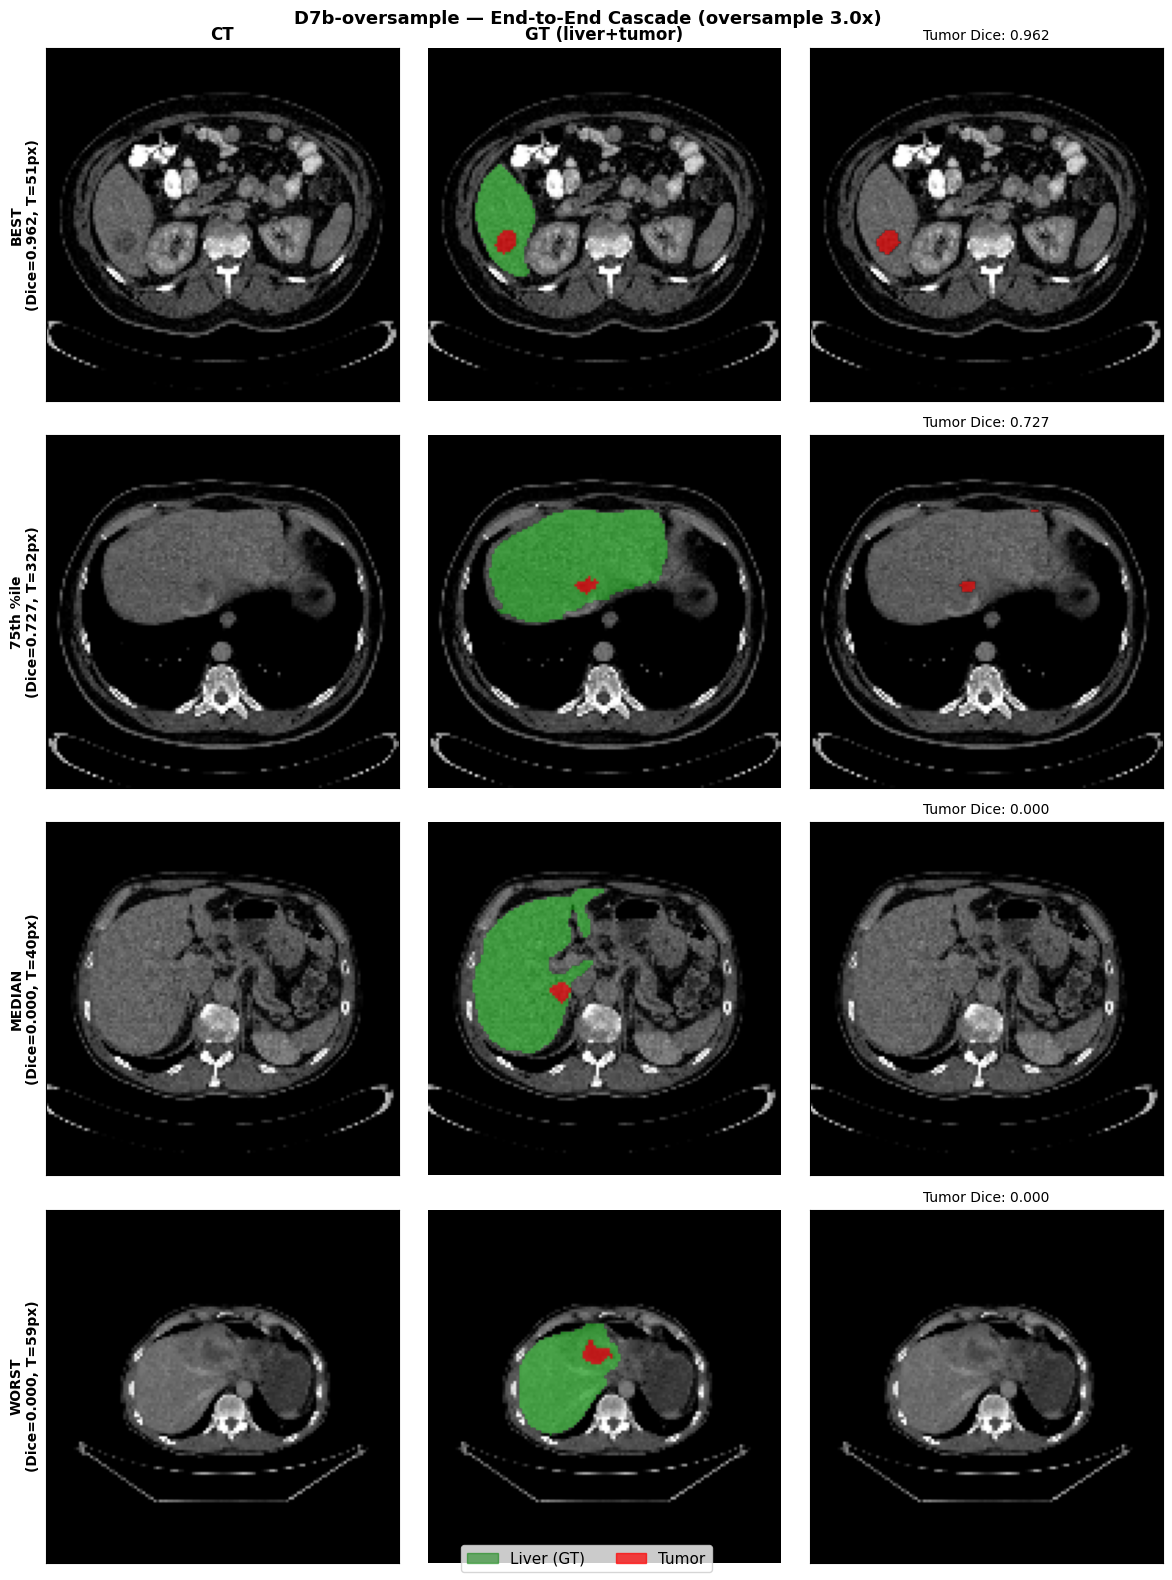

In [11]:
if e2e_samples:
    e2e_samples.sort(key=lambda s: s['dice'], reverse=True)
    n_total = len(e2e_samples)
    picks = [(0, 'BEST'),
             (n_total // 4, '75th %ile'),
             (n_total // 2, 'MEDIAN'),
             (n_total - 1, 'WORST')] if n_total >= 4 else [(i, f'#{i}') for i in range(n_total)]

    def overlay(seg_3cls, _ct):
        o = np.zeros((*_ct.shape, 4))
        o[seg_3cls == 1] = [0, 1, 0, 0.35]
        o[seg_3cls == 2] = [1, 0, 0, 0.65]
        return o

    def overlay_tumor(tumor_mask, _ct):
        o = np.zeros((*_ct.shape, 4))
        o[tumor_mask == 1] = [1, 0, 0, 0.65]
        return o

    n = len(picks)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    if n == 1: axes = [axes]
    for col, t in enumerate(['CT', 'GT (liver+tumor)', 'Cascade tumor pred']):
        axes[0][col].set_title(t, fontsize=12, fontweight='bold')
    for row, (i, lbl) in enumerate(picks):
        s = e2e_samples[i]
        ct, gt, pr, d = s['ct'], s['gt'], s['pred_tumor'], s['dice']
        axes[row][0].imshow(ct.T, cmap='gray', origin='lower')
        axes[row][0].set_ylabel(f'{lbl}\n(Dice={d:.3f}, T={s["tumor_px"]}px)',
                                fontsize=10, fontweight='bold')
        axes[row][0].set_xticks([]); axes[row][0].set_yticks([])
        axes[row][1].imshow(ct.T, cmap='gray', origin='lower')
        axes[row][1].imshow(overlay(gt, ct).transpose(1,0,2), origin='lower')
        axes[row][1].axis('off')
        axes[row][2].imshow(ct.T, cmap='gray', origin='lower')
        axes[row][2].imshow(overlay_tumor(pr, ct).transpose(1,0,2), origin='lower')
        axes[row][2].set_title(f'Tumor Dice: {d:.3f}', fontsize=10)
        axes[row][2].set_xticks([]); axes[row][2].set_yticks([])
    g = mpatches.Patch(color='green', alpha=0.5, label='Liver (GT)')
    r = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
    fig.legend(handles=[g, r], loc='lower center', ncol=2, fontsize=11)
    plt.suptitle(f'{TAG} — End-to-End Cascade (oversample {OVERSAMPLE_RATIO}x)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'qualitative_d7b.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No qualitative samples collected.')